In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")
np.random.seed(42)

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier

In [5]:
# 1. 데이터 로드 및 전처리
df = pd.read_csv("supervised_label_cn7.csv")
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
df

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,9.60,4.48,16.910000,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,...,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.600000
1,0,9.59,4.48,16.910000,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,...,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.600000
2,0,9.58,4.46,16.900000,59.580002,7.13,653.409973,68.839996,647.98999,55.599998,...,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,67.500000,25.000000,27.600000
3,0,9.58,4.46,16.920000,59.560001,7.13,653.409973,68.849998,647.98999,55.500000,...,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,67.000000,25.000000,27.600000
4,0,9.57,4.45,16.910000,59.520000,7.14,653.409973,68.830002,647.98999,55.700001,...,59.099998,275.700012,274.899994,274.799988,270.799988,255.399994,230.100006,66.699997,24.799999,27.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6731,0,9.58,4.46,16.670000,59.520000,7.11,653.429993,68.339996,647.98999,55.200001,...,59.700001,275.799988,275.500000,275.500000,269.500000,255.000000,230.199997,66.000000,21.000000,22.400000
6732,0,9.60,4.49,16.650000,59.540001,7.11,653.429993,68.320000,647.98999,54.900002,...,59.799999,276.100006,275.899994,274.899994,269.700012,254.600006,229.600006,65.400002,21.000000,22.400000
6733,0,9.60,4.48,16.620001,59.560001,7.11,653.429993,68.330002,647.98999,54.900002,...,59.900002,276.500000,274.899994,275.100006,269.500000,255.600006,229.600006,66.099998,21.000000,22.400000
6734,0,9.60,4.48,16.650000,59.560001,7.11,653.429993,68.349998,647.98999,55.000000,...,59.900002,275.799988,275.299988,275.500000,270.700012,254.899994,230.000000,66.099998,21.000000,22.400000


In [6]:
X = df.drop(columns=["PassOrFail"])
y = df["PassOrFail"]

In [7]:
X.shape, y.shape

((6736, 24), (6736,))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
# ---------------------------------------------------------
# 2. 모델별 하이퍼파라미터 그리드 설정 (AutoML 핵심)
# ---------------------------------------------------------
# 튜닝하고 싶은 모델과 파라미터 범위를 정의합니다.
models_to_tune = {
    "RF": {
        "model": RandomForestClassifier(random_state=42, class_weight="balanced"),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    },
    "GBM": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "learning_rate": [0.01, 0.1],
            "n_estimators": [100, 200],
            "max_depth": [3, 5]
        }
    },
    "LR": {
        "model": LogisticRegression(max_iter=3000, random_state=42),
        "params": {
            "C": [0.1, 1.0, 10.0]
        }
    }
}

In [10]:
# ---------------------------------------------------------
# 3. 자동 튜닝 및 최적 모델 추출
# ---------------------------------------------------------
best_estimators = []
tuning_results = []

print("=== 하이퍼파라미터 최적화 시작 ===")
for name, config in models_to_tune.items():
    print(f"Tuning {name}...")
    grid = GridSearchCV(config["model"], config["params"], cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    display(grid.best_params_)
    pred = best_model.predict(X_test)
    display(confusion_matrix(y_test, pred))
    best_estimators.append((name, best_model)) # Stacking용

    # 평가
    pred = best_model.predict(X_test)
    tuning_results.append({
        "Model": name,
        "Best_Params": grid.best_params_,
        "Accuracy": accuracy_score(y_test, pred),
        "F1_Score": f1_score(y_test, pred)
    })

# 튜닝 결과 확인
tuning_df = pd.DataFrame(tuning_results).sort_values("F1_Score", ascending=False)
print("\n=== 개별 모델 튜닝 결과 ===")
print(tuning_df)

=== 하이퍼파라미터 최적화 시작 ===
Tuning RF...


{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

array([[1337,    3],
       [   3,    5]])

Tuning GBM...


{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

array([[1340,    0],
       [   3,    5]])

Tuning LR...


{'C': 10.0}

array([[1340,    0],
       [   3,    5]])


=== 개별 모델 튜닝 결과 ===
  Model                                        Best_Params  Accuracy  F1_Score
1   GBM  {'learning_rate': 0.01, 'max_depth': 3, 'n_est...  0.997774  0.769231
2    LR                                        {'C': 10.0}  0.997774  0.769231
0    RF  {'max_depth': None, 'min_samples_split': 2, 'n...  0.995549  0.625000


In [11]:
# ---------------------------------------------------------
# 4. 최종 병기: Stacking Ensemble
# ---------------------------------------------------------
# 위에서 튜닝된 최적의 모델들을 기반으로 스태킹 수행
print("\n=== 최종 Stacking 모델 구성 및 학습 ===")
stacking_model = StackingClassifier(
    estimators=best_estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stacking_model.fit(X_train, y_train)
final_pred = stacking_model.predict(X_test)


=== 최종 Stacking 모델 구성 및 학습 ===


In [12]:
# ---------------------------------------------------------
# 5. 최종 결과 리포트
# ---------------------------------------------------------
final_f1 = f1_score(y_test, final_pred)
final_acc = accuracy_score(y_test, final_pred)

print("\n" + "="*50)
print("🏆 FINAL STACKING MODEL PERFORMANCE 🏆")
print(f"Accuracy : {final_acc:.4f}")
print(f"F1-Score : {final_f1:.4f}")
print("="*50)
print(classification_report(y_test, final_pred))


🏆 FINAL STACKING MODEL PERFORMANCE 🏆
Accuracy : 0.9978
F1-Score : 0.7692
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       1.00      0.62      0.77         8

    accuracy                           1.00      1348
   macro avg       1.00      0.81      0.88      1348
weighted avg       1.00      1.00      1.00      1348



In [13]:
cm = confusion_matrix(y_test, final_pred)
cm

array([[1340,    0],
       [   3,    5]])

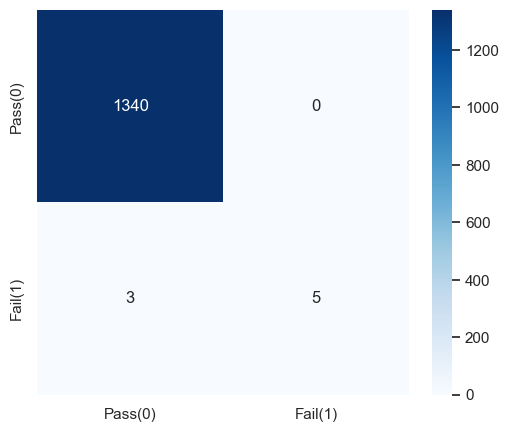

In [14]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pass(0)', 'Fail(1)'],
            yticklabels=['Pass(0)', 'Fail(1)'])
plt.show()

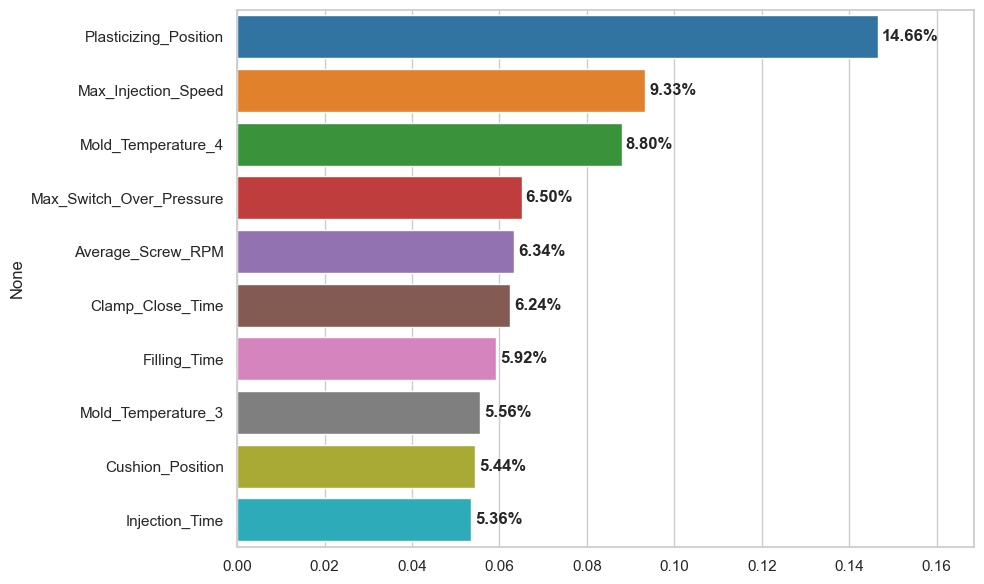

In [15]:
best_rf = [m for n, m in best_estimators if n == "RF"][0]
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_10 = feat_imp.head(10)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_10.values, y=top_10.index, hue=top_10.index, palette="tab10", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt='{:.2%}', padding=3, fontweight='bold')
plt.xlim(0, top_10.max() * 1.15)
plt.tight_layout()
plt.show()

In [16]:
# end